In [1]:
# TRABAJO PRÁCTICO INTEGRADO: BIENESTAR DIGITAL (ETAPA 6)
# LIBRERÍAS UTILIZADAS:
# - pandas: Para la manipulación, limpieza y estructuración de los datos.
# - numpy: Para operaciones matemáticas vectoriales y cálculo de signos.
# - matplotlib.pyplot: Para la generación y personalización de gráficos.
# - sklearn (scikit-learn): Para el ajuste y evaluación del modelo de regresión.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("tpi_datos.csv")

In [4]:
#primero extremos las columnas necesarias 

horas_redes = df["Horas de  consumo de redes sociales por día"] #variable independiente 
rendimiento = df["Rendimieno académico"] #variable dependiente 


In [5]:
#construccion de la tabla de frecuencias

fi = horas_redes.value_counts().sort_index()#con value_counts() contamos cuantas veces se repite cada valor y con sotr.index() ordenamos los valores medidos cronologicamente de menor a mayor

Fi = fi.cumsum()  #con cumsum se suman de forma progresiva los valores anteriores

fri = horas_redes.value_counts(normalize=True).sort_index() #con normalize=True, dividimos automáticamente cada conteo por el total de la  muestra (N)

Fri = fri.cumsum()

#creamos un diccionario para armar la tabla de frecuencias 
tabla_frecuencias = pd.DataFrame({
    'fi (Frec. Absoluta)': fi,
    'Fi (Frec. Abs. Acumulada)': Fi,
    'fri (Frec. Relativa)': fri,
    'Fri (Frec. Rel. Acumulada)': Fri
})

print("\n--- TABLA DE FRECUENCIAS COMPLETA ---")
tabla_frecuencias


--- TABLA DE FRECUENCIAS COMPLETA ---


,fi (Frec. Absoluta),Fi (Frec. Abs. Acumulada),fri (Frec. Relativa),Fri (Frec. Rel. Acumulada)
Horas de consumo de redes sociales por día,,,,
0,11,11,0.022449,0.022449
1,18,29,0.036735,0.059184
2,52,81,0.106122,0.165306
3,102,183,0.208163,0.373469
4,92,275,0.187755,0.561224
5,81,356,0.165306,0.726531
6,44,400,0.089796,0.816327
7,45,445,0.091837,0.908163
8,17,462,0.034694,0.942857


In [6]:
#CALCULO DE PARAMETROS CENTRALES Y DISPERSION

media_horas = horas_redes.mean() #con .mean se suman todos los valores de la columna y se los divide por la cantida
desviacion_horas = horas_redes.std() #.std calcula la desviación estándar muestral

print(f"\nMedia de horas calculada: {media_horas:.2f}")
print(f"Desviación estándar calculada: {desviacion_horas:.2f}")



Media de horas calculada: 4.47
Desviación estándar calculada: 2.24


In [7]:
#ahora vamos a interpretar la información utilizando los parametros de la OMS

if media_horas > 3:
    print(f"La media de la muestra ({media_horas:.2f} hs) supera el límite de 3 horas")
    print("Por lo tanto, es mandatorio activar laSegunda etapa (plan de acción de reducción)")
    print("ACCIONES PARA REDUCIR EL CONSUMO DE PANTALLA")
    print(f"""
    - Establecer límites diarios de uso para las pantallas más utilizadas.
    - Desactivar notificaciones innecesarias que generan distracciones.
    - Evitar el uso del celular durante las comidas.
    - Reducir el tiempo dedicado a redes sociales.
    - Realizar actividades recreativas sin dispositivos electrónicos.
    - Mantener el celular fuera del alcance durante las horas de estudio.""")

else:
    print(f"BIENESTAR: El promedio muestral respeta los límites saludables según la OMS")

La media de la muestra (4.47 hs) supera el límite de 3 horas
Por lo tanto, es mandatorio activar laSegunda etapa (plan de acción de reducción)
ACCIONES PARA REDUCIR EL CONSUMO DE PANTALLA

    - Establecer límites diarios de uso para las pantallas más utilizadas.
    - Desactivar notificaciones innecesarias que generan distracciones.
    - Evitar el uso del celular durante las comidas.
    - Reducir el tiempo dedicado a redes sociales.
    - Realizar actividades recreativas sin dispositivos electrónicos.
    - Mantener el celular fuera del alcance durante las horas de estudio.


In [8]:
print("ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL - ETAPA 5")

#Modelado de regresión lineal y correlación

# Scikit-learn requiere obligatoriamente que la variable independiente X sea una matriz bidimensional (filas, columnas). .values.reshape(-1, 1) transforma el vector unidimensional en una estructura de matriz compatible de una sola columna.
X = horas_redes.values.reshape(-1, 1)

Y = rendimiento.values

#declaramos el modelo de regresión lineal vacío
modelo = LinearRegression()

#lo entrenamos pasandole los datos de x e y para que calcule la recta
modelo.fit(X, Y)

#guardamos el valor de la ordenada al origen
intercept = modelo.intercept_

# y acá guardamos el valor de la pendiente de la recta 
slope = modelo.coef_

#calculamos los puntos teóricos de la recta para hacer las predicciones 
Y_pred = modelo.predict(X)

#calculamos el coeficiente de determinacion
r_cuadrado = r2_score(Y, Y_pred)

#sacamos la raíz de R cuadrado para tener el coeficiente r
r_correlacion = np.sign(slope) * np.sqrt(r_cuadrado)

print(f"c) Ecuación de la recta: Y = {intercept:.4f} + ({slope[0]:.4f}) * X")
print(f"d) Pendiente (b): {slope[0]:.4f}")
print(f"e) Coeficiente de correlación lineal (r): {r_correlacion[0]:.4f}")
print(f"f) Coeficiente de determinación (R²): {r_cuadrado:.4f}")


ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL - ETAPA 5
c) Ecuación de la recta: Y = 8.0568 + (-0.2189) * X
d) Pendiente (b): -0.2189
e) Coeficiente de correlación lineal (r): -0.5831
f) Coeficiente de determinación (R²): 0.3400


In [9]:
#Ahora las interpretaciones automáticas

#Acá el programa analiza le signo de la pendiente y explica su significado 
# Acá el programa analiza el signo de la pendiente y te explica qué significa
print("\n>>> INTERPRETACIÓN DE LA PENDIENTE:")
if slope[0] < 0:
    print(f"La pendiente es negativa ({slope[0]:.4f}). Por cada hora extra de redes sociales,")
    print(f"el rendimiento académico disminuye en promedio {abs(slope[0]):.4f} puntos.")
else:
    print(f"La pendiente es positiva ({slope[0]:.4f}). Por cada hora extra de redes sociales,")
    print(f"el rendimiento académico aumenta en promedio {slope[0]:.4f} puntos.")

# Acá el programa clasifica qué tan fuerte o débil es la relación entre las cosas
print("\n>>> INTERPRETACIÓN DE LA CORRELACIÓN (r):")
fuerza = "fuerte" if abs(r_correlacion[0]) > 0.7 else ("moderada" if abs(r_correlacion[0]) > 0.4 else "débil")
sentido = "inversa (negativa)" if r_correlacion[0] < 0 else "directa (positiva)"
print(f"Existe una correlación lineal {fuerza} e {sentido} entre ambas variables.")

# Acá explica el porcentaje de influencia que tienen las redes sobre las notas
print("\n>>> INTERPRETACIÓN DE LA DETERMINACIÓN (R²):")
print(f"El {r_cuadrado * 100:.2f}% de la variación en el rendimiento académico")
print("se explica por el tiempo diario asignado al uso de redes sociales.")


>>> INTERPRETACIÓN DE LA PENDIENTE:
La pendiente es negativa (-0.2189). Por cada hora extra de redes sociales,
el rendimiento académico disminuye en promedio 0.2189 puntos.

>>> INTERPRETACIÓN DE LA CORRELACIÓN (r):
Existe una correlación lineal moderada e inversa (negativa) entre ambas variables.

>>> INTERPRETACIÓN DE LA DETERMINACIÓN (R²):
El 34.00% de la variación en el rendimiento académico
se explica por el tiempo diario asignado al uso de redes sociales.


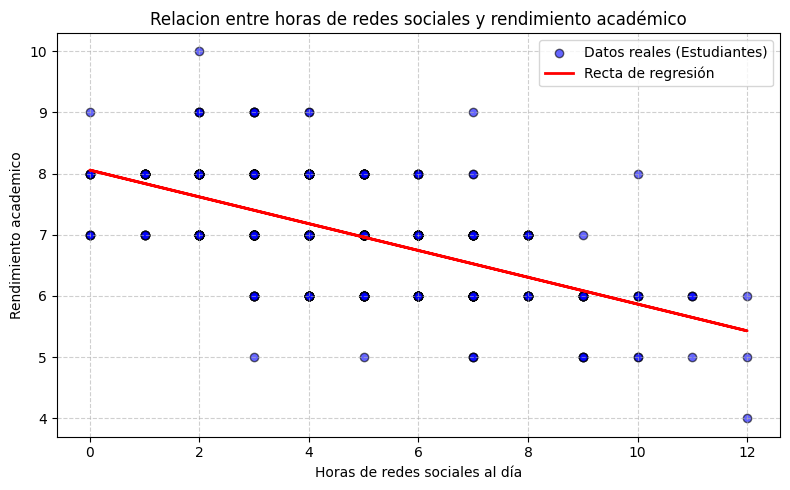

In [10]:
#DIAGRAAMS DE DISPERSIÓN

#primero se define el tamaño de ventana donde se va a dibujar el gráfico
plt.figure(figsize=(8, 5))

#dibujamos los puntitos con los datos reales de los alumnos 
plt.scatter(X, Y,
            color='blue', 
            alpha=0.6, 
            edgecolors='k', 
            label='Datos reales (Estudiantes)'
            )

#dibujamos la linea roja que representa la recta de regresion 
plt.plot(X, Y_pred,
        color='red',
        linewidth=2, 
        label='Recta de regresión'
        )

#acá le designamos los títulos y nombres a las opciones
plt.title("Relacion entre horas de redes sociales y rendimiento académico")
plt.xlabel("Horas de redes sociales al día", fontsize=10)
plt.ylabel("Rendimiento academico", fontsize=10)

#activamos el recuadro (leyenda) que muestra la referencia de que significan los colores 
plt.legend()

#le agregamos lineas de fondo tipo cuadricula para que se lea todo mejor
plt.grid(True, linestyle="--", alpha=0.6)

#esto es mas que nada para que no se core ningún texto al mostrarlo
plt.tight_layout()

#abrimos la ventana que muestra el gráfico terminadito :D
plt.show()

INTERPRETACIÓN DEL GRÁFICO

El gráfico muestra que existe un impacto negativo en el rendimiento académico a mayor exposición de pantallas. La pendiente negativa de la recta lineal confirma de forma visual que, en promedio, cadad hora adicional en redes sociales sociales deprime la calificación estimada del estudiante. La dispersión de los puntos nos indica que, si bien la tendencia es calra, el rendimiento escolar está afectado por múltiples factores además del bienestar digital. 